# Gaussian Process tool

This notebook is a walkthrough for the pipeline used by the GP reconstruction code

In [1]:
import sys
import pprint
import seaborn as sb
import numpy   as np
import pandas  as pd
import random  as rnd

from copy    import deepcopy
from time    import time
from tqdm    import tqdm

from getdist import plots,MCSamples

#Plotting
import matplotlib
import matplotlib.pyplot as plt

from matplotlib import rc


rc('text', usetex=True)
rc('font', family='serif')
matplotlib.rcParams.update({'font.size': 18})

red    = '#8e001c'
yellow = '#ffb302'

sidelegend = {'bbox_to_anchor': (1.04,0.5), 
              'loc': "center left",
              'frameon': False}
bottomlegend = {'bbox_to_anchor': (0.35,-0.2), 
                'loc': "center left",
                'frameon': False,
                'ncols': 3}

In [2]:
possible_derivatives = ['f','int','d1','d2']

# Preliminaries

Some things to do at the beginning so that we can enjoy a wonderful GP experience

## Settings

Here we specify the fixed settings of the reconstruction, namely the number and distribution of the $x$ points where the reconstruction is performed

In [3]:
N_recon    = 20
xmin_recon = 0.
xmax_recon = 2.
x_recon = np.linspace(xmin_recon,xmax_recon,N_recon)

## Sampling settings (used for all samplings)

Two settings exist as pre-coded: `poor` and `good` for quick or robust samplings.

The `sampler_option` variable can also be a dictionary containing the relevant options of the chosen sampler

In [4]:
#sampler = 'emcee'
sampler = 'nautilus'
samper_options = 'poor'

## Theoretical function

In [5]:
def get_theory(coeffs):

    from numpy.polynomial import Polynomial
    
    p = Polynomial(coeffs)
    # Compute derivatives and integral using NumPy's built-in methods
    p_deriv1 = p.deriv(m=1)   # First derivative
    p_deriv2 = p.deriv(m=2)   # Second derivative
    p_integ  = p.integ(m=1)   # Antiderivative (integration constant C=0)
    results = {'f': lambda x: p(x),
               'd1': lambda x: p_deriv1(x),
               'd2': lambda x: p_deriv2(x),
               'int': lambda x: p_integ(x)}
    return results

## Create data to be reconstructed

Here we simulate data and errors for a completely made up observable

$$f(x) = \sum_{i=0}^N{a_ix^i}$$

where $N$ is the order of the polynomial and $a_i$ are the parameters controlling the $x$ trend of the observable

### Data settings

Settings controlling the data quality: number of measurements and their error

In [6]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

### Theory model

In [7]:
fiducial = {'a0': 3,
            'a1': -1,
            'a2': 5,
            'a3': -0.1
           }

theory_model = get_theory(list(fiducial.values()))

### Data generation

In [8]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_model['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f'] = np.random.normal(thvals,errors)
dataset['f_err'] = errors

covmat = pd.DataFrame(np.diag(errors*2),columns=['f_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat.index = covmat.columns

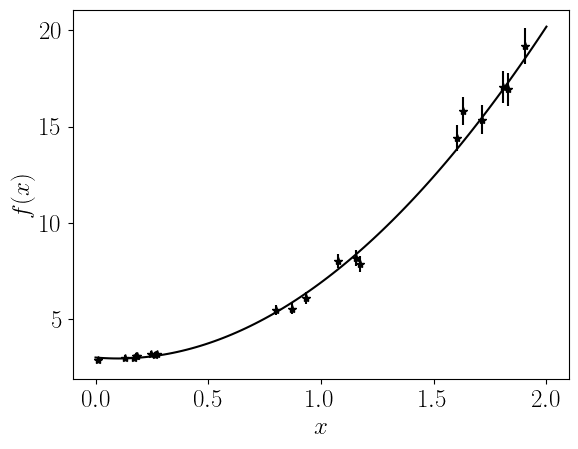

In [9]:
xplot = np.linspace(xmin,xmax,100)
plt.figure()
plt.plot(xplot,theory_model['f'](xplot),color='black')
plt.errorbar(dataset['x'],dataset['f'],yerr=dataset['f_err'],color='black',ls='',marker='*')
plt.xlabel(x_label)
plt.ylabel(y_label);

# Gaussian process

A Gaussian Process (GP) is the generalisation of a Gaussian distribution where, instead of looking at a random variable, we look at a distribution over functions.

Given a set of observational data $\mathbf{y}$ at positions $\mathbf{X}=\{x_i\}$, in the GP approach we assume that these are Gaussian representation of the underlying function $f(x)$

$$\mathbf{y}\sim\mathcal{N}(\mathbf{\mu},K(\mathbf{X},\mathbf{X})+C)\,,$$

where $\mathbf{\mu}$ is the mean of the distribution, $K(\mathbf{X},\mathbf{X})$ is the covariance matrix of the normal distribution and $C$ is the observational covariance which accounts for the measurement error.

This means that a new vector of values $\mathbf{f}^*$ for the underlying function at a set of points $\mathbf{X}^*$ can be written as 

$$\mathbf{f}^*\sim\mathcal{N}(\mathbf{\mu}^*,K(\mathbf{X}^*,\mathbf{X}^*))\,.$$

Jointly, the two GP for $\mathbf{y}$ and $\mathbf{f}^*$ can be written as

$$\begin{bmatrix} \mathbf{y} \\ \mathbf{f}^* \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} \mathbf{\mu} \\ \mathbf{\mu}^* \end{bmatrix}, \begin{bmatrix} K(\mathbf{X},\mathbf{X}) + C & K(\mathbf{X},\mathbf{X}^*) \\ K(\mathbf{X}^*,\mathbf{X}) & K(\mathbf{X}^*,\mathbf{X}^*) \end{bmatrix} \right)$$

The $\mathbf{y}$ points are known from observations, while we want to obtain the values of $\mathbf{f}^*$.

The mean and covariance of these values can be obtained as **REF**

$$\mathbf{f}^* = K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

$$\text{cov}(\mathbf{f}^*) = K(\mathbf{X}^*,\mathbf{X}^*) - K(\mathbf{X},\mathbf{X}^*) (K(\mathbf{X},\mathbf{X}) + C)^{-1} K(\mathbf{X}^*,\mathbf{X})$$


where we assumed $\mathbf{\mu}=\mathbf{\mu}^*=0$. (**explain why this is good**)


In the context of GP, the covariance $K$ is known as *Kernel* and can be chosen between different possibilities. Kernels contain some free parameters known as *hyper-parameters*.


Choosing the hyper-parameters (see below) and a Kernel, one can therefore obtain predictions for the target function at a set of $\mathbf{X}^*$ points, based on the observed $\mathbf{y}$.

Aside from the usefullness of reconstructing the target function, GP have another very useful property: the result of performing a linear operation on a GP returns a function that is still a GP **REF**.

This means that if we want to obtain the derivative of the target function (${\rm d}\,f/{\rm d}\,x$), once we reconstruct the function $f(x)$ with a GP, the derivative can be rewritten as

$$\mathbf{f}'^* = \frac{\partial K(\mathbf{X},\mathbf{X}^*)}{\partial \mathbf{X}_*} (K(\mathbf{X},\mathbf{X}) + C)^{-1} \mathbf{y}\,,$$

with the derivative covariance being

$$\text{cov}(f'(x), f'(x')) = \frac{\partial^2}{\partial x \partial x'} k(x, x')$$

and the covariance between the function and the derivative being

$$\text{cov}(f(x), f'(x')) = \frac{\partial}{\partial x'} k(x, x')$$

This holds not just for the first derivative but also for higher orders (as long as one can obtain derivatives of the kernel) and integrals. We refer to **REF** for a more extended discussion

## The GP class: GPCalculator

The `GPCalculator` class is the engine of the GP reconstruction part of CoRe, designed to transform discrete, noisy data into continuous functional reconstructions. It is written in **JAX** for high-performance, differentiable linear algebra.

### 1. Initialization and Data Structuring
Upon initialization, the class ingests your data and covariance matrices. 
* **Multi-Output Support:** It automatically detects if you are reconstructing a single function or multiple correlated functions (e.g., $f_1$ and $f_2$). 
* **Flattening:** To handle multi-output systems, it flattens the training data into a single vector and constructs a joint noise covariance matrix to account for cross-correlations in the data.

### 2. Kernel and Operator Algebra
The core of the GP is the kernel $K(x, x')$. A unique feature of this class is its ability to reconstruct not just the function $f(x)$, but also its derivatives and integrals:
* **Automatic Differentiation:** Using JAX's `grad` and `vmap`, the class computes the kernels for the first derivative ($d1$), second derivative ($d2$), and the integral ($int$) of the primary function.
* **Cross-Covariance:** It builds a massive joint covariance matrix that describes how $f$ correlates with its own derivatives and integrals, ensuring physical consistency across all reconstructed quantities.

### 3. Inference Engine
The class provides two pathways to determine the hyperparameters (lengthscale $\ell$ and amplitude $\sigma$):
* **MAP (Maximum A Posteriori):** Optimizes the Marginal Log-Likelihood using `scipy.optimize`. This is fast and provides a single "best-fit" reconstruction.
* **Bayesian Sampling:** Interfaces with the `Nautilus` sampler to explore the hyperparameter posterior. It generates a distribution of possible GPs and marginalizes over them using the **Law of Total Variance** to produce honest, robust error bars.

### 4. Unpacking and Results
After the calculation, the `_unpack` method deconstructs the high-dimensional joint covariance matrix back into:
* **Mean DataFrames:** Containing the reconstructed values for $f, f', f''$, and $\int f$.
* **Joint Covariance Matrix:** A full $4N \times 4N$ (or $8N \times 8N$) matrix providing the correlations between every point across every operator.

In [10]:
from CoRe.reconstruction_tools.GaussianProcess import GPCalculator

## Choosing hyper-parameters

The choice of hyper-parameters can be handled by the GPCalculator class, which offers the possibility
to switch between an optimization approach and a marginalization approach.

For this example we fix the kernel to RBF

In [11]:
reconstructions = {}

In [12]:
gp = GPCalculator(dataset,covmat,kernel_type='RBF',chatty=True)

Initialized GPCalculator with 1 output(s): ['f']
Kernel: RBF | Available Operators: ['f', 'd1', 'd2', 'int']


## Hyperparameter Optimization: MAP Method

The **Maximum A Posteriori (MAP)** approach seeks to find the specific values of the hyperparameters $\theta = \{\ell, \sigma_f\}$ that maximize the posterior probability density. 

### The Objective Function
In practice, we minimize the **Negative Log-Posterior**:

$$\mathcal{L}_{MAP}(\theta) = -\log p(y | X, \theta) - \log p(\theta)$$

Where:
* $-\log p(y | X, \theta)$ is the **Marginal Log-Likelihood**, which balances the "model fit" against the "complexity penalty" (determinant of the covariance matrix).
* $-\log p(\theta)$ represents the **Priors** on our hyperparameters, preventing them from reaching unphysical values (e.g., a lengthscale of zero or infinity).

### Characteristics
* **Efficiency:** Uses gradient-based optimizers (like L-BFGS-B or Adam via JAX) to find the peak of the distribution quickly.
* **Point Estimate:** It provides a single "best-fit" curve. It does not account for the uncertainty *in the hyperparameters themselves*, only the uncertainty of the GP given those fixed parameters.
* **Risk:** If the likelihood surface is multimodal (has many peaks), the optimizer might get stuck in a local optimum rather than the global best fit.

> **When to use:** Use MAP when computational speed is a priority or when the data is high-quality enough that the posterior is sharply peaked.

In [13]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP')

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Optimized'] = {'Functions': means,
                                'Covmat': joint_cov}

best_fit = info['Best-fit']

best_fit['logl']     = np.log(best_fit['l'])
best_fit['logsigma'] = np.log(best_fit['sigmas'][0])

Optimizing (MAP) to find hyper-parameter centers...
GP done in 5.75 s


## Hyperparameter Inference: Full Bayesian Method

Unlike MAP, the **Full Bayesian** approach accounts for our lack of knowledge regarding the "true" hyperparameters. Instead of picking one value, we marginalize over the entire posterior distribution $p(\theta | y, X)$.

### The Process
1.  **Sampling:** We use a Sampler (e.g., Nested Sampling via `Nautilus`) to draw thousands of samples from the hyperparameter posterior.
2.  **Weighting:** Each sample represents a valid GP model. Some might have long lengthscales (smooth curves), while others have short ones (wiggly curves).
3.  **Marginalization:** The final reconstruction is the **weighted average** of all these possible GPs.

### The Law of Total Variance
The uncertainty in a Bayesian GP comes from two sources:
1.  **Process Uncertainty:** The inherent variance of the GP given a fixed $\theta$.
2.  **Parameter Uncertainty:** The variance caused by the fact that we aren't sure what $\theta$ actually is.

The total predictive covariance is calculated as:
$$\Sigma_{total} = \mathbb{E}_\theta[\Sigma_{GP}(\theta)] + \text{Var}_\theta[\mu_{GP}(\theta)]$$

### Characteristics
* **Robustness:** Naturally handles "heavy-tailed" distributions or multimodality in the parameter space.
* **Honest Errors:** Usually produces larger, more "honest" error bars because it captures the uncertainty of the hyperparameters.
* **Cost:** Computationally expensive, as it requires running the GP likelihood thousands of times.

> **When to use:** Use the Bayesian method for final scientific results where rigorous error propagation is essential.

In [14]:
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',
                                             sampler_name=sampler,sampler_options=samper_options,n_samples=100)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Marginalized'] = {'Functions': means,
                                   'Covmat': joint_cov}

sample = info['sample']

Optimizing (MAP) to find hyper-parameter centers...
MAP found at: [0.45268746 2.79546596]. Setting informative priors for sampling...
Sampling (MCMC) for 1 outputs...
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 12     | 1        | 2        | 13184    | N/A    | 10024 | -31.37   
NAUTILUS SAMPLING FINISHED
Removed no burn in
Vectorizing predictions for 100 samples...
GP done in 48.02 s


### Visualize hyper-parameters

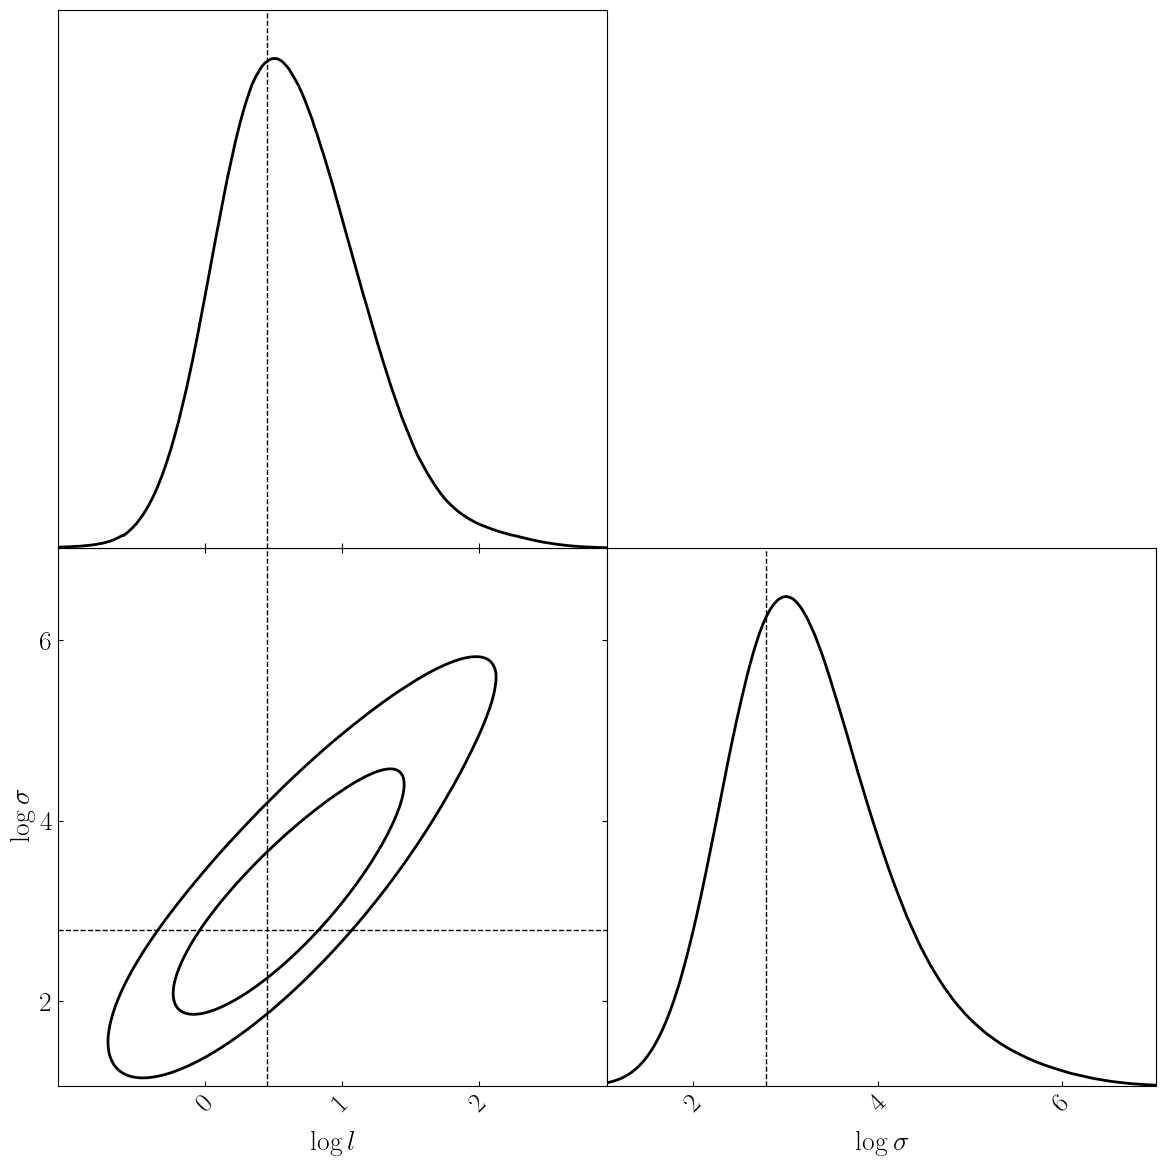

In [15]:
g = plots.get_subplot_plotter(subplot_size=1,width_inch=12, scaling=False)

g.settings.figure_legend_frame = False
g.settings.axes_fontsize=20
g.settings.axes_labelsize=20
g.settings.legend_fontsize=20
g.settings.axis_marker_color = 'black'
g.settings.axis_marker_ls = '--'
g.settings.axis_marker_lw = 1
g.settings.axis_tick_x_rotation = 45
g.triangle_plot(sample,['logl','logsigma'],legend_loc='upper right',
                filled=False,contour_lws=2,
                markers=best_fit
               )
g.fig.align_ylabels()
g.fig.align_xlabels();

### Comparison

In [16]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Method'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

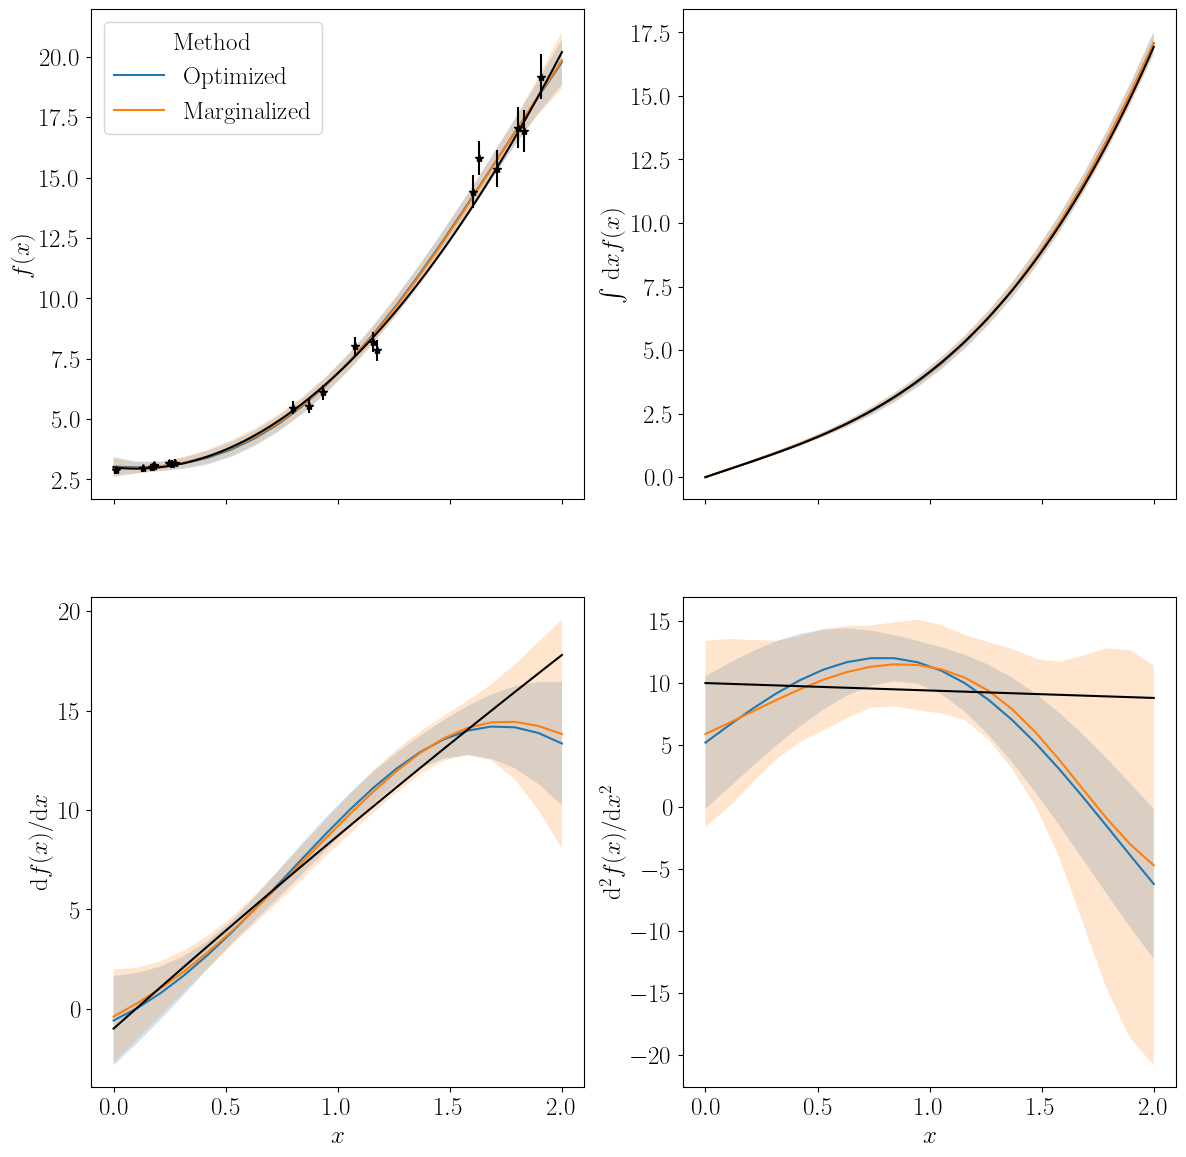

In [17]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Method'].unique():
        df = results[results['Method']==method]
        axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Method',ax=axes[i,j],legend=0)
    axes[i,j].plot(xplot,theory_model[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

## Available GP Kernels: Smoothness and Prior Assumptions

The kernel function $K(x, x')$ determines the correlation between two points in the reconstruction. The choice of kernel is a choice of **functional prior**: it tells the GP how "smooth" or "wiggly" the underlying cosmology is expected to be.

### 1. Radial Basis Function (RBF)
Also known as the **Squared Exponential** kernel, this is the most common choice in GP literature.

* **Formula:** $K(x, x') = \sigma^2 \exp\left( -\frac{|x - x'|^2}{2\ell^2} \right)$
* **Smoothness:** Infinitely differentiable ($C^\infty$).
* **Physical Assumption:** The RBF kernel assumes a very smooth, analytic underlying function. 
* **When to use:** Ideal for global cosmological trends that are expected to be slowly varying and devoid of sharp features or phase transitions.

---

### 2. Matérn 3/2
The Matérn class of kernels allows for less stringent smoothness requirements compared to the RBF.

* **Formula:** $K(x, x') = \sigma^2 \left( 1 + \frac{\sqrt{3}|x - x'|}{\ell} \right) \exp\left( -\frac{\sqrt{3}|x - x'|}{\ell} \right)$
* **Smoothness:** Once differentiable ($C^1$). 
* **Physical Assumption:** It assumes a "rougher" function. The realizations are continuous and have a continuous first derivative, but the second derivative may be jagged.
* **When to use:** Use this when the data suggests more localized variability that the RBF might "over-smooth" or ignore.

---

### 3. Matérn 5/2
This kernel sits in the middle ground between the "infinite smoothness" of the RBF and the "roughness" of the Matérn 3/2.

* **Formula:** $K(x, x') = \sigma^2 \left( 1 + \frac{\sqrt{5}|x - x'|}{\ell} + \frac{5|x - x'|^2}{3\ell^2} \right) \exp\left( -\frac{\sqrt{5}|x - x'|}{\ell} \right)$
* **Smoothness:** Twice differentiable ($C^2$).
* **Physical Assumption:** Realizations are twice-differentiable. This is often the "Goldilocks" kernel for cosmology, as many physical quantities (like the growth rate or luminosity distance) depend on the first or second derivatives of the scale factor.
* **When to use:** Generally recommended as a default when you want a robust reconstruction that isn't as restrictive as the RBF.

---

In the `GPCalculator`, these can be toggled by setting the `kernel_type` parameter to `'RBF'`, `'MATERN3/2'`, or `'MATERN5/2'`.

In [18]:
available_kernels = ['RBF','MATERN3/2','MATERN5/2']

In [19]:
reconstructions = {}

In [20]:
for kernel in available_kernels:

    gp = GPCalculator(dataset,covmat,kernel_type=kernel,chatty=True)

    tini = time()
    means, joint_cov, lml, info = gp.reconstruct(x_recon,method='MAP',n_samples=100,sampler_name=sampler,sampler_options=samper_options)
    
    print('GP with {} done in {:.2f} s'.format(kernel,time()-tini))
    
    reconstructions[kernel] = {'Functions': means,
                               'Covmat': joint_cov}

Initialized GPCalculator with 1 output(s): ['f']
Kernel: RBF | Available Operators: ['f', 'd1', 'd2', 'int']
Optimizing (MAP) to find hyper-parameter centers...
GP with RBF done in 1.84 s
Initialized GPCalculator with 1 output(s): ['f']
Kernel: MATERN3/2 | Available Operators: ['f', 'd1', 'int']
Optimizing (MAP) to find hyper-parameter centers...
GP with MATERN3/2 done in 3.61 s
Initialized GPCalculator with 1 output(s): ['f']
Kernel: MATERN5/2 | Available Operators: ['f', 'd1', 'd2', 'int']
Optimizing (MAP) to find hyper-parameter centers...
GP with MATERN5/2 done in 11.01 s


/home/Matteo/Codes/CoRe/CoRe/reconstruction_tools/GaussianProcess.py:228: RuntimeWarning: invalid value encountered in sqrt
  mean_df[f"{col}_err"] = np.sqrt(np.diag(covmat_df.loc[labels, labels].values))


In [21]:
dfs = []

for name,recon in reconstructions.items():
    df = pd.DataFrame(recon['Functions'])
    df['Kernel'] = name
    dfs.append(df)

results = pd.concat(dfs,ignore_index=True)

### Comparison

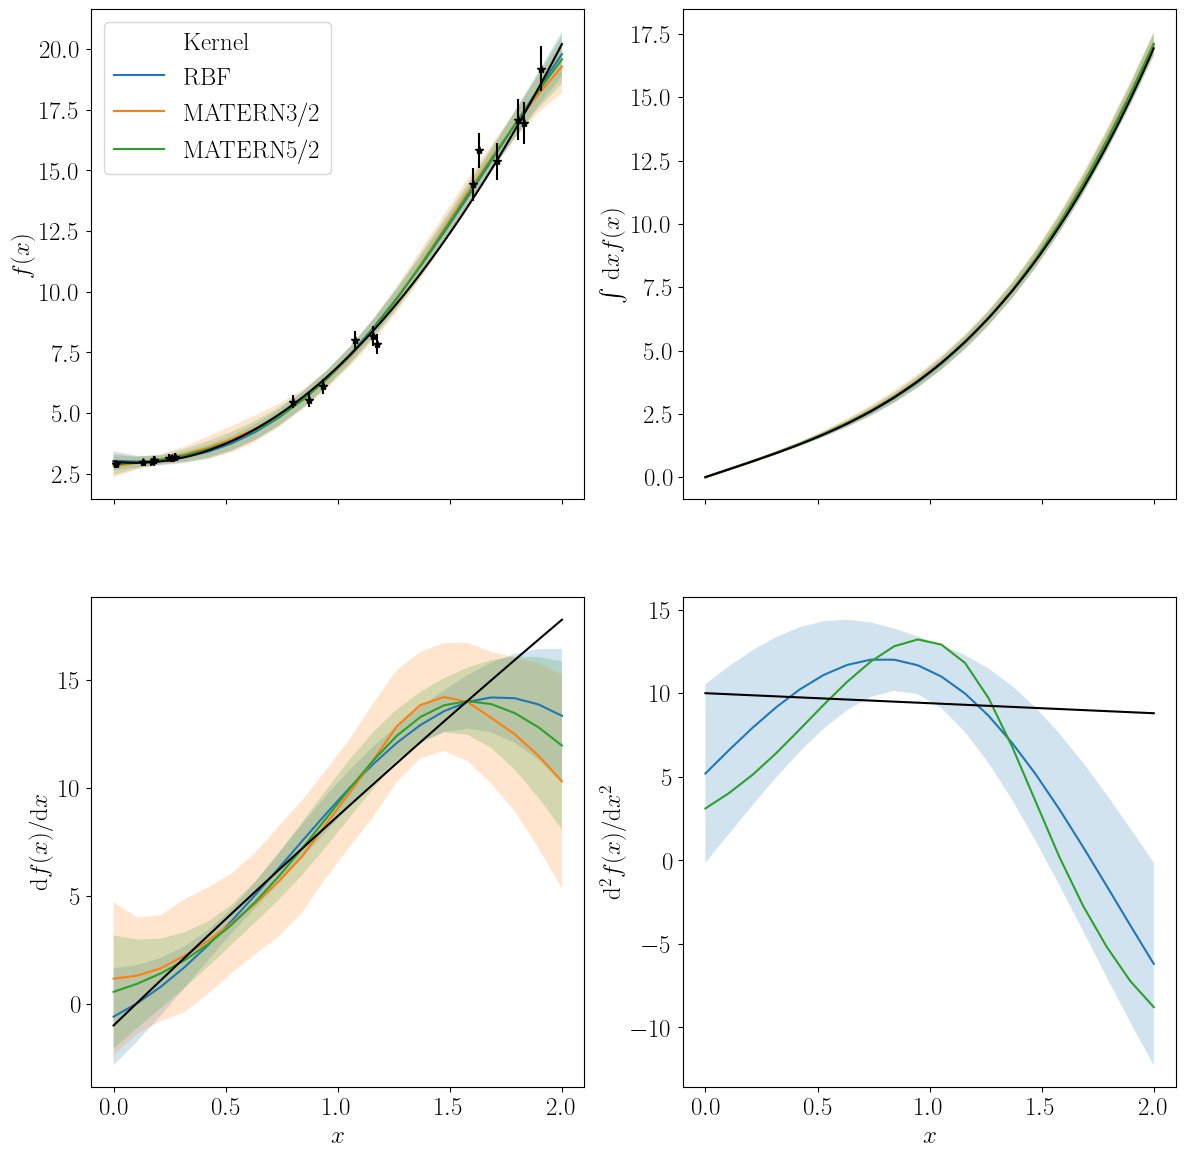

In [22]:
xplot = np.linspace(xmin,xmax,100)
fig,axes = plt.subplots(nrows=2,ncols=2,sharey=False,sharex=True,figsize=(14,14))

for ind,deriv in enumerate(possible_derivatives):
    if ind == 0:
        i = 0
        j = 0
        label = y_label
    elif ind == 1:
        i = 0
        j = 1
        label = r'$\int$ d'+x_label+''+y_label
    elif ind == 2:
        i = 1
        j = 0
        label = r'd'+y_label+'/d'+x_label
    elif ind == 3:
        i = 1
        j = 1
        label = r'd$^2$'+y_label+'/d'+x_label+r'$^2$'

    for method in results['Kernel'].unique():
        df = results[results['Kernel']==method]
        if len(df) != 0:
            axes[i,j].fill_between(x_recon,df[deriv]+df[deriv+'_err'],df[deriv]-df[deriv+'_err'],alpha=0.2)
    if ind == 0:
        sb.lineplot(results,x='x',y=deriv,hue='Kernel',ax=axes[i,j])
    else:
        sb.lineplot(results,x='x',y=deriv,hue='Kernel',ax=axes[i,j],legend=0)
    axes[i,j].plot(xplot,theory_model[deriv](xplot),color='black')
    if deriv == 'f':
        axes[i,j].errorbar(dataset['x'],dataset[deriv],yerr=dataset[deriv+'_err'],color='black',ls='',marker='*')
    axes[i,j].set_xlabel(x_label)
    axes[i,j].set_ylabel(label)

# GP diagnostics

In [23]:
from CoRe.utils.diagnostics import Scorer

In [24]:
score = {}

In [25]:
for k,v in reconstructions.items():
    score[k] = Scorer(v['Functions'],v['Covmat'],chatty=True,eigen_trunc_factor=1.e-5)

## Mahalanobis score

In [26]:
theory_df = pd.DataFrame({'x': x_recon}|{func: theory_model[func](x_recon) for func in ['f','d1','d2','int']})

In [27]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_theory(theory_df)


RBF

 SCORE REPORT: THEORY CONSISTENCY
Status (Full System): POOR (Significant Tension)
Full Total Chi2:      1156706.50
Full Red.  Chi2:      14458.831
Full P-value:         0.0000
Full DOF:             80
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       16.42
Truncated Red. Chi2:  2.053
Truncated P-value:    0.0367
Truncated DOF:        8 (Dropped 72 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 2.52e+02         | 1.25          |   0.0%     | KEPT
Mode 1    | 7.90e+01         | 4.69          |   0.0%     | KEPT
Mode 2    | 3.22e+01         | 0.96          |   0.0%     | KEPT
Mode 3    | 5.09e+00         | 1.01          |   0.0%     | KEPT
Mode 4    | 3.40e+00         | 0.01          |   0.0%     | KE

## Pointwise $\chi^2$ Scoring

In [28]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_pointwise(theory_df)


RBF

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): GOOD (Consistent)
Full Total Chi2:      44.59
Full Red.  Chi2:      0.557
Full P-value:         0.9995
Full DOF:             80

Pointwise Component Breakdown:
  - f    :     4.35 (  9.8%)
  - d1   :    11.08 ( 24.8%)
  - d2   :    28.21 ( 63.3%)
  - int  :     0.96 (  2.1%)


MATERN3/2

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): GOOD (Consistent)
Full Total Chi2:      13.68
Full Red.  Chi2:      0.228
Full P-value:         1.0000
Full DOF:             60

Pointwise Component Breakdown:
  - f    :     4.85 ( 35.5%)
  - d1   :     7.31 ( 53.4%)
  - int  :     1.52 ( 11.1%)


MATERN5/2

 SCORE REPORT: POINTWISE THEORY CONSISTENCY
Status (Full System): GOOD (Consistent)
Full Total Chi2:      15.38
Full Red.  Chi2:      0.192
Full P-value:         1.0000
Full DOF:             80

Pointwise Component Breakdown:
  - f    :     4.40 ( 28.6%)
  - d1   :     9.87 ( 64.2%)
  - d2   :    -0.01 ( -0.0%)


## Scoring Against Data (Consistency)

In [29]:
datasets = [{'type': 'f',
             'df': dataset,
             'cov': covmat}]

In [30]:
for k,v in score.items():
    print('')
    print(k)
    res = v.score_against_data(datasets)


RBF

 SCORE REPORT: EXTERNAL DATA VALIDATION
Status (Full System): GOOD (Consistent)
Full Total Chi2:      2.94
Full Red.  Chi2:      0.147
Full P-value:         1.0000
Full DOF:             20
------------------------------------------------------------
Truncated Subspace Metrics (Cutoff Factor F = 1e-05):
Truncated Chi2:       2.94
Truncated Red. Chi2:  0.147
Truncated P-value:    1.0000
Truncated DOF:        20 (Dropped 0 noisy modes)

Eigenmode Spectrum Breakdown (Sorted by Eigenvalue / Variance Descending):
Mode ID   | Eigenvalue (Var) | Chi2 Contrib  | Percentage | Status  
---------------------------------------------------------------------------
Mode 0    | 3.29e+00         | 0.04          |   1.3%     | KEPT
Mode 1    | 1.90e+00         | 0.11          |   3.8%     | KEPT
Mode 2    | 1.73e+00         | 0.24          |   8.3%     | KEPT
Mode 3    | 1.68e+00         | 0.04          |   1.4%     | KEPT
Mode 4    | 1.52e+00         | 0.47          |  15.9%     | KEPT
Mode 5    |

# Gaussian Process reconstruction for correlated data

## Reconstructing Correlated Data: Multi-Output GPs

In many cosmological scenarios, we are not just observing a single isolated function. We often have datasets that are physically related or even measured from the same survey, leading to cross-correlations in the noise. The `GPCalculator` is designed to handle this via a **Multi-Output (Vector-Valued)** GP approach.

### 1. The Joint Data Vector
Instead of treating datasets separately, we concatenate them into a single "super-vector" $\mathbf{y}$. For two observables $f_1$ and $f_2$:

$$\mathbf{y} = \begin{bmatrix} \vec{y}_{f1} \\ \vec{y}_{f2} \end{bmatrix}$$

Similarly, the noise is represented by a **Block-Diagonal Covariance Matrix** (or a dense matrix if cross-correlations are known):

$$\mathbf{C} = \begin{bmatrix} \mathbf{C}_{11} & \mathbf{C}_{12} \\ \mathbf{C}_{21} & \mathbf{C}_{22} \end{bmatrix}$$

### 2. Coupled Kernels
The `GPCalculator` builds a joint kernel matrix $\mathbf{K}$ that describes both the auto-correlation (how $f_1$ relates to itself) and the cross-correlation (how $f_1$ relates to $f_2$).

* **Auto-correlation:** $\text{Cov}(f_1(x), f_1(x')) = K_{11}(x, x')$
* **Cross-correlation:** $\text{Cov}(f_1(x), f_2(x')) = K_{12}(x, x')$

This ensures that the reconstruction of one function is "informed" by the data of the other. If the two functions are theoretically linked (for example, if $f_2$ is the derivative of $f_1$), the GP enforces this physical relationship exactly through the properties of linear operators on kernels.

### 3. Why This Matters for Cosmology
* **Consistent Inference:** If $H(z)$ and $d_L(z)$ data are used together, the GP ensures that the reconstructed expansion history is consistent with the reconstructed distance scale.
* **Information Gain:** Data from a high-precision probe (like SNe Ia) can help "tighten" the reconstruction of a noisier correlated probe (like $H(z)$).
* **Systematics Control:** By including the cross-covariance $\mathbf{C}_{12}$ in the noise matrix, the GP correctly penalizes the fit if the two datasets have shared systematic errors.

### 4. Implementation in `GPCalculator`
The class automatically detects multiple output columns in your input dataframe. It then:
1.  **Stacks** the data and noise matrices correctly.
2.  **Solves** the GP equations once for the entire joint system.
3.  **Unpacks** the result into individual means and a full joint covariance matrix that tracks how the uncertainty in $f_1$ is correlated with the uncertainty in $f_2$ at every redshift.

**Further discussion of correlated GP can be found in [Perenon et al. Phys.Dark Univ. 34 (2021)](https://arxiv.org/abs/2105.01613)**

Here we create the data for two functions $f_1(x)$ and $f_2(x)$ assuming including a correlation between the measurements 
of each function when they are performed at the same $x$. 
We assume the correlation factor to be uniformly distributed between 0 and 1 

In [31]:
Ndata   = 20
xmin    = 0
xmax    = 2
err_fac = 5

x_label = r'$x$'
y_label = r'$f(x)$'

In [32]:
fiducial_func1 = {'a0': 3,
                  'a1': -1}

theory_func_1 = get_theory(list(fiducial_func1.values()))

In [33]:
fiducial_func2 = {'a0': 3,
                  'a1': -1,
                  'a2': 5}

theory_func_2 = get_theory(list(fiducial_func2.values()))

**DATA FORMAT FOR CORRELATED DATA**

In order to work with GP on correlated functions, the dataset should be provide as a DataFrame containing the columns

`x, f1, f2`

while the covariance should have as columns (and index)

`f1_0 ... f1_N, f2_0 ... f2_N`

with $N$ the number of data points.

In [34]:
dataset = pd.DataFrame({'x': np.random.uniform(xmin,xmax,Ndata)})

thvals = theory_func_1['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f1'] = np.random.normal(thvals,errors)
dataset['f1_err'] = errors

thvals = theory_func_2['f'](dataset['x'])
errors = abs(thvals)*err_fac/100
dataset['f2'] = np.random.normal(thvals,errors)
dataset['f2_err'] = errors

dataset['r(f1,f2)'] = np.random.uniform(0,1,len(dataset))
dataset

,x,f1,f1_err,f2,f2_err,"r(f1,f2)"
0,0.356989,2.569688,0.132151,3.235970,0.164011,0.408460
1,0.302137,2.520544,0.134893,3.166373,0.157715,0.304159
2,0.304206,2.704926,0.134790,3.088096,0.157925,0.176853
3,1.472128,1.462399,0.076394,13.024591,0.618184,0.074292
4,1.486195,1.514459,0.075690,12.344623,0.627884,0.318156
5,0.516327,2.440722,0.124184,4.180899,0.190832,0.312962
6,0.374236,2.605437,0.131288,3.229577,0.166301,0.076404
7,0.665906,2.419864,0.116705,5.056539,0.227562,0.982938
8,0.924607,2.086852,0.103770,6.519819,0.317494,0.950568
9,0.942881,2.237390,0.102856,6.391133,0.325112,0.455941


In [35]:
covmat_1 = pd.DataFrame(np.diag(errors*2),columns=['f1_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_1.index = covmat_1.columns

covmat_2 = pd.DataFrame(np.diag(errors*2),columns=['f2_{}'.format(ind) for ind in range(len(dataset['x']))])
covmat_2.index = covmat_2.columns

cov_cross = np.diag([row['f1_err']*row['f2_err']*row['r(f1,f2)'] for ind,row in dataset.iterrows()])

joint_matrix = np.block([[covmat_1.values,  cov_cross],
                         [cov_cross.T, covmat_2.values]])

N = len(dataset)
labels = [f"f1_{i}" for i in range(N)] + [f"f2_{i}" for i in range(N)]
covmat = pd.DataFrame(joint_matrix, columns=labels, index=labels)

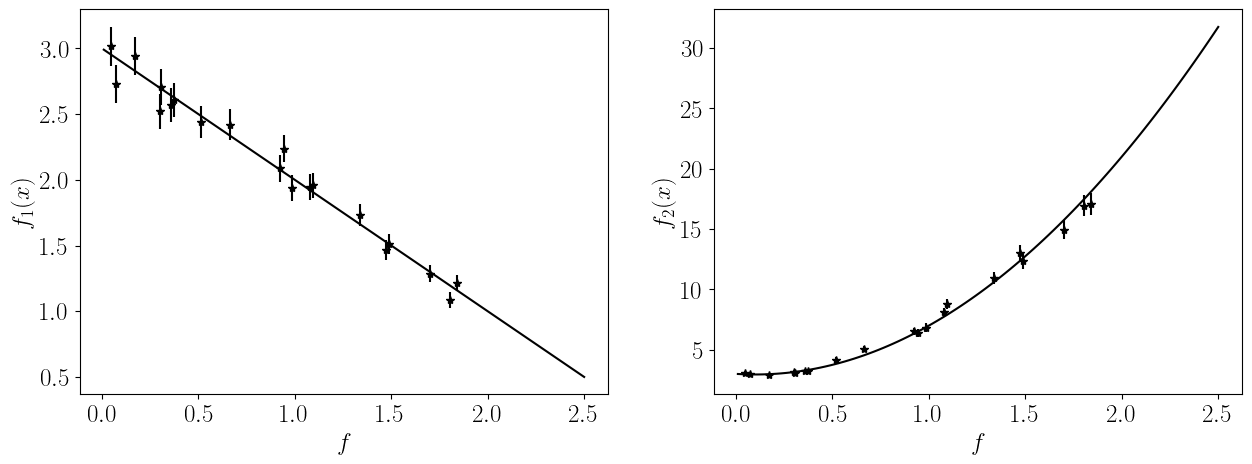

In [36]:
xplot = np.linspace(0.01,2.5,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))

axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$f$')
axes[0].set_ylabel(r'$f_1(x)$')

axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$f$')
axes[1].set_ylabel(r'$f_2(x)$');

In [37]:
reconstructions = {}

## Uncorrelated reconstruction

In [38]:
dataset_1 = dataset.copy()
dataset_1 = dataset_1[['x','f1','f1_err']].rename(columns={'f1': 'f','f1_err': 'f_err'})

In [39]:
gp = GPCalculator(dataset_1,covmat_1,kernel_type='RBF',chatty=True)
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100,sampler_name=sampler,sampler_options=samper_options)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Func1'] = {'Functions': means,
                            'Covmat': joint_cov}

Initialized GPCalculator with 1 output(s): ['f']
Kernel: RBF | Available Operators: ['f', 'd1', 'd2', 'int']
Optimizing (MAP) to find hyper-parameter centers...
MAP found at: [1.05355891 0.87308908]. Setting informative priors for sampling...
Sampling (MCMC) for 1 outputs...



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [05:01<00:00,  9.94it/s]

EMCEE SAMPLING FINISHED
Removed no burn in
Vectorizing predictions for 100 samples...
GP done in 314.01 s


In [40]:
dataset_2 = dataset.copy()
dataset_2 = dataset_2[['x','f2','f2_err']].rename(columns={'f2': 'f','f2_err': 'f_err'})

In [41]:
gp = GPCalculator(dataset_2,covmat_2,kernel_type='RBF',chatty=True)
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100,sampler_name=sampler,sampler_options=samper_options)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Func2'] = {'Functions': means,
                            'Covmat': joint_cov}

Initialized GPCalculator with 1 output(s): ['f']
Kernel: RBF | Available Operators: ['f', 'd1', 'd2', 'int']
Optimizing (MAP) to find hyper-parameter centers...
MAP found at: [0.52366911 2.72348467]. Setting informative priors for sampling...
Sampling (MCMC) for 1 outputs...



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [05:19<00:00,  9.38it/s]

EMCEE SAMPLING FINISHED
Removed no burn in
Vectorizing predictions for 100 samples...
GP done in 325.94 s


## Correlated reconstruction

In [42]:
dataset = dataset.drop(columns=['r(f1,f2)'])
gp = GPCalculator(dataset,covmat,kernel_type='RBF',chatty=True)
tini = time()
means, joint_cov, lml, info = gp.reconstruct(x_recon,method='BAYESIAN',n_samples=100,sampler_name=sampler,sampler_options=samper_options)

print('GP done in {:.2f} s'.format(time()-tini))

reconstructions['Correlated'] = {'Functions': means,
                                 'Covmat': joint_cov}

Initialized GPCalculator with 2 output(s): ['f1', 'f2']
Kernel: RBF | Available Operators: ['f', 'd1', 'd2', 'int']
Optimizing (MAP) to find hyper-parameter centers...
MAP found at: [ 0.65702169  0.69311929  2.90151685 -0.07959347]. Setting informative priors for sampling...
Sampling (MCMC) for 2 outputs...



00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [04:43<00:00, 10.58it/s]

EMCEE SAMPLING FINISHED
Removed no burn in
Vectorizing predictions for 100 samples...
GP done in 288.17 s


## Plotting

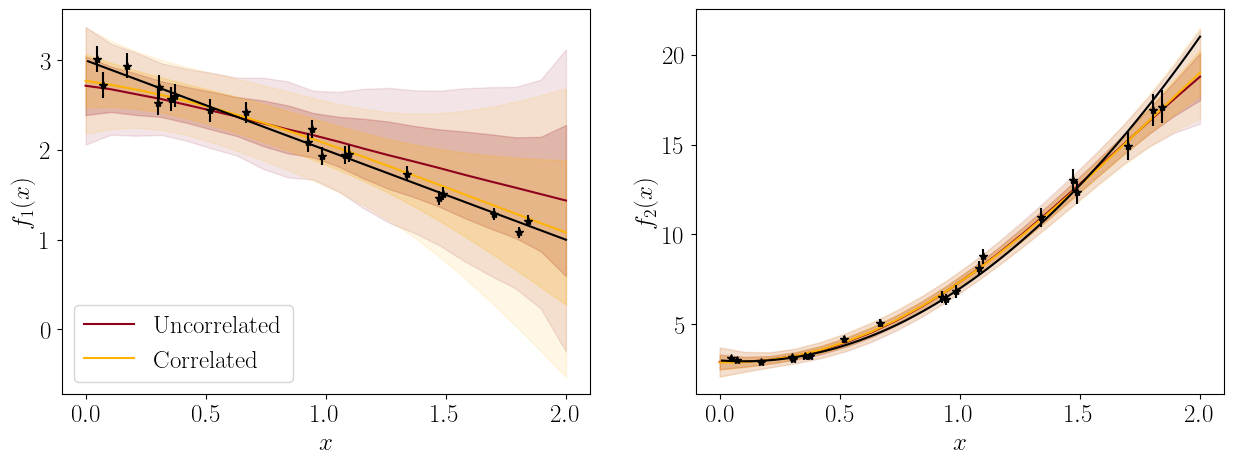

In [43]:
xplot = np.linspace(0.01,2.,100)

fig,axes = plt.subplots(nrows=1,ncols=2,sharey=False,sharex=True,figsize=(15,5))
df =  reconstructions['Func1']['Functions']
axes[0].fill_between(df['x'],df['f']+2*df['f_err'],df['f']-2*df['f_err'],alpha=0.1,color=red)
axes[0].fill_between(df['x'],df['f']+df['f_err'],df['f']-df['f_err'],alpha=0.2,color=red)
axes[0].plot(df['x'],df['f'],color=red,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[0].fill_between(df['x'],df['f1']+2*df['f1_err'],df['f1']-2*df['f1_err'],alpha=0.1,color=yellow)
axes[0].fill_between(df['x'],df['f1']+df['f1_err'],df['f1']-df['f1_err'],alpha=0.2,color=yellow)
axes[0].plot(df['x'],df['f1'],color=yellow,label='Correlated')
axes[0].plot(xplot,theory_func_1['f'](xplot),color='black')
axes[0].errorbar(dataset['x'],dataset['f1'],yerr=dataset['f1_err'],color='black',ls='',marker='*')
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$f_1(x)$')
axes[0].legend(loc='best')



df =  reconstructions['Func2']['Functions']
axes[1].fill_between(df['x'],df['f']+2*df['f_err'],df['f']-2*df['f_err'],alpha=0.1,color=red)
axes[1].fill_between(df['x'],df['f']+df['f_err'],df['f']-df['f_err'],alpha=0.2,color=red)
axes[1].plot(df['x'],df['f'],color=red,label='Uncorrelated')
df =  reconstructions['Correlated']['Functions']
axes[1].fill_between(df['x'],df['f2']+2*df['f2_err'],df['f2']-2*df['f2_err'],alpha=0.1,color=yellow)
axes[1].fill_between(df['x'],df['f2']+df['f2_err'],df['f2']-df['f2_err'],alpha=0.2,color=yellow)
axes[1].plot(df['x'],df['f2'],color=yellow,label='Correlated')
axes[1].plot(xplot,theory_func_2['f'](xplot),color='black')
axes[1].errorbar(dataset['x'],dataset['f2'],yerr=dataset['f2_err'],color='black',ls='',marker='*')
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$f_2(x)$');